<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Deslocamentos transversais de vigas

### Problema 5

A figura representa a viga ABCD, que suporta uma carga distribuída trapezoidal $Q(x)$ e uma carga concentrada $P$. Considere $Q_C = 20$ kN/m, $Q_D = 40$ kN/m, $P = 40$ kN, $L = 6$ m.

a) Utilizando funções de singularidade escreva a equação do momento fletor para toda a viga.

b) Trace os diagramas do esforço transverso e do momento fletor entre A e D.

c) Determine a equação da linha elástica.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au08/P5/MSII_Au08_P5.png"
style="max-width: 100%;"/>



### Resolução

#### a) Utilizando funções de singularidade escreva a equação do momento fletor para toda a viga.

#### b) Trace os diagramas do esforço transverso e do momento fletor entre A e D.


In [12]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '1'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

def printsymSF(expr):
    expr2 = sy.simplify(sy.factor(expr))
    return expr2.xreplace({n : round(n, 3) for n in expr.atoms(sy.Number)})

# data structure, units: N, mm, MPa

class varin: pass

d = varin()

d.L = 6.  # unit: m
d.P = 40. # unit: kN
d.QC = 20. # unit: kN/m
d.QD = 40. # unit: kN/m

# assumindo
EI = 1

#### Força linearmente distribuida

- Resultante da força distribuida

\begin{equation*}
Q_{eq} = \int_{x_C}^{x_D} Q(x) \mathrm{d}x
\quad\wedge\quad
Q(x) - Q_C = \frac{Q_D-Q_C}{x_D-x_C}(x-x_C)
\end{equation*}

- Coordenada do centroide da linha de acção da força resultante

\begin{equation*}
\overline{x} = \left(\int_{x_C}^{x_D} Q(x) x \mathrm{d}x \right) / Q_{eq}
\end{equation*}


In [13]:
from scipy import integrate
# scipy.integrate is a module that contains functions for integration.
# Integration can be performed on a function defined by a lambda
# Integration can also be performed given an array of y values
import numpy as np
import sympy as sy
from sympy.solvers import solve

x = sy.symbols('x')

xC, xD = d.L/2,d.L
def Q(x): return d.QC + (d.QD-d.QC)/(xD-xC)*(x-xC)
print(f' Q(x) = {printsymSF(Q(x))} [kN]')
intQ = integrate.quad(Q,d.L/2,d.L)
Qeq = intQ[0]
print(f' Qeq = {Qeq:.1f} [kN]')

def Qx(x): return Q(x)*x
print(f' Q(x).x = {printsymSF(Qx(x))} [kN]')
intQx = integrate.quad(Qx,d.L/2,d.L)
Qcent = intQx[0]/Qeq
print(f' Qcent = {intQx[0]:.1f} / {Qeq:.1f} = {Qcent:.1f} [m]')

 Q(x) = 6.667*x [kN]
 Qeq = 90.0 [kN]
 Q(x).x = 6.667*x**2 [kN]
 Qcent = 420.0 / 90.0 = 4.7 [m]


In [14]:
ax, ay, dy = sy.symbols('ax ay dy')

print('::: sistema de equações :::')
sumFX = ax
print(f'sumFX = {sumFX} [kN]')
sumFY = ay + dy - d.P - Qeq
print(f'sumFY = {sumFY} [kN]')
sumMD = -d.L/4*d.P - Qcent*Qeq + d.L*dy
print(f'sumMD = {sumMD} [kN.m]')
sol = solve([sumFX,sumFY,sumMD],[ax, ay, dy])

::: sistema de equações :::
sumFX = ax [kN]
sumFY = ay + dy - 130.0 [kN]
sumMD = 6.0*dy - 480.0 [kN.m]


In [15]:
print('-------------------')
print('Reações')
print('-------------------')
Ax, Ay, Dy = sol[ax], sol[ay], sol[dy]
print(f'RAx  = {Ax:.1f} kN')
print(f'RAy  = {Ay:.1f} kN')
print(f'RBy  = {Dy:.1f} kN')

-------------------
Reações
-------------------
RAx  = 0.0 kN
RAy  = 50.0 kN
RBy  = 80.0 kN



#### Funções de singularidade


<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au08/P5/FunSing.png"
width="900">

#### Esforço transverso

- Expressão do eforço transverso escrita com base em funções de singularidade

\begin{equation*}
V(x) = \frac{\mathrm{d}M(x)}{\mathrm{d}x}
= A_y <x-0>^0 - P<x-\frac{L}{4}>^0
- \underbrace{Q_C<x-\frac{L}{2}>^1}_{\textrm{uniforme}}
- \underbrace{\frac{m}{2}<x-\frac{L}{2}>^2}_{\textrm{triangular}}
+ \underbrace{D_{y} <x-L>^0}_{off}
\end{equation*}

com,

\begin{equation*}
m = \frac{(Q_D-Q_C)}{(x_D-x_C)} = \frac{(Q_D-Q_C)}{(L-L/2)}
= \frac{2(Q_D-Q_C)}{L}
\end{equation*}


**Diagrama de esforço transverso**

- Tramo AB

\begin{equation*}
V_{AB}(x) = A_y
\end{equation*}

- Tramo BC

\begin{equation*}
V_{BC}(x) = A_y - P
\end{equation*}

- Tramo CD

\begin{equation*}
V_{CD}(x) = A_y - P - Q_C \left(x-\frac{L}{2}\right)
- \left(\frac{Q_D-Q_C}{L}\right) \left(x-\frac{L}{2}\right)^2
\end{equation*}

vAB = 50.0
vBC = 10.0
vCD = 40.0 - 3.33333333333333*x**2


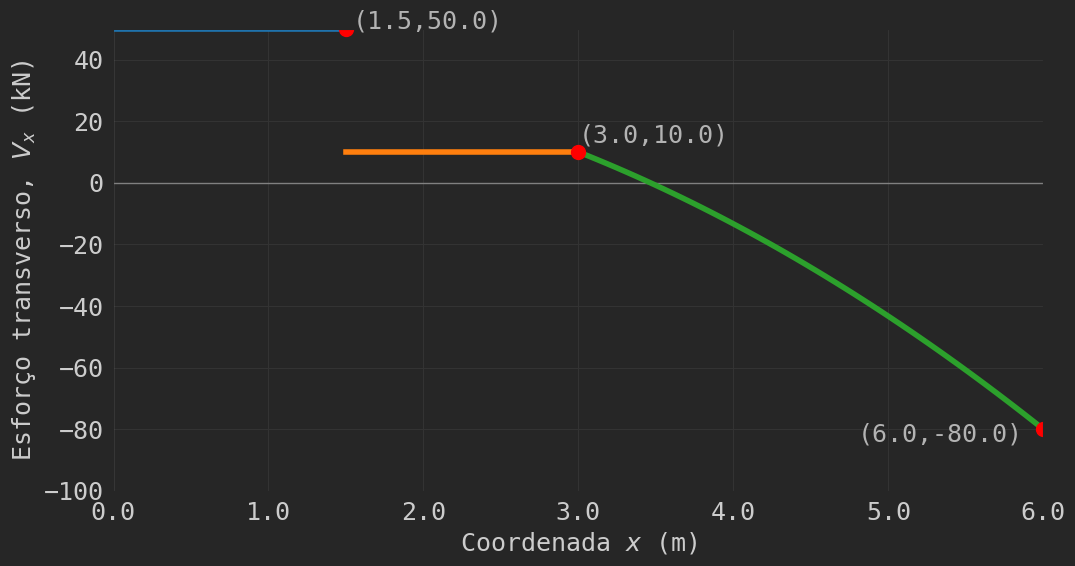

In [16]:

xAB = np.linspace(0,d.L/4)
xBC = np.linspace(d.L/4,d.L/2)
xCD = np.linspace(d.L/2,d.L)

def sy2array(sygunc,xlist):
    scalar_func = lambda xx: float(sygunc.evalf(subs={x: xx}))
    vector_func = np.vectorize(scalar_func)
    return vector_func(xlist)

vAB = lambda x: Ay
vBC = lambda x: Ay - d.P
vCD = lambda x: Ay - d.P - d.QC*(x-d.L/2) - (d.QD-d.QC)/d.L*(x-d.L/2)**2

print(f'vAB = {vAB(x):.1f}')
print(f'vBC = {vBC(x):.1f}')
print(f'vCD = {printsymSF(vCD(x))}')

# AB
yvAB = sy2array(vAB(x),xAB)
# BC
yvBC = sy2array(vBC(x),xBC)
# CD
yvCD = sy2array(vCD(x),xCD)

fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=1,color=(.5, .5, .5))
plt.plot(xAB,yvAB,linewidth=4)
plt.plot(xBC,yvBC,linewidth=4)
plt.plot(xCD,yvCD,linewidth=4)
plt.plot(xAB[-1],yvAB[-1],'ro',markersize=10)
plt.text(xAB[-1]*1.03,yvAB[-1]*1.,f'({xAB[-1]:.1f},{yvAB[-1]:.1f})',fontsize=18)
plt.plot(xBC[-1],yvBC[-1],'ro',markersize=10)
plt.text(xBC[-1],yvBC[-1]*1.3,f'({xBC[-1]:.1f},{yvBC[-1]:.1f})',fontsize=18)
plt.plot(xCD[-1],yvCD[-1],'ro',markersize=10)
plt.text(xCD[-1]*.8,yvCD[-1]*1.05,f'({xCD[-1]:.1f},{yvCD[-1]:.1f})',fontsize=18)
plt.xlabel(r'Coordenada $x$ (m)')
plt.ylabel(r'Esforço transverso, $V_{x}$ (kN)')
plt.xlim(0,d.L)
plt.ylim(-100,50)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
xrang = np.arange(0, d.L*1.1, 1.0)
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
plt.grid(True)
plt.show()


#### Momento fletor

- Expressão do momento fletor escrita com base em funções de singularidade

\begin{equation*}
M(x) - M(0)= \int_0^x V(x) \mathrm{d}x =  A_y <x-0>^1 - P<x-\frac{L}{4}>^1
- \underbrace{\frac{Q_C}{2}<x-\frac{L}{2}>^2}_{\textrm{uniforme}}
- \underbrace{\frac{m}{(2)(3)}<x-\frac{L}{2}>^3}_{\textrm{triangular}}
+ \underbrace{D_{y} <x-L>^1}_{off}
\end{equation*}

com,

\begin{equation*}
m = \frac{(Q_D-Q_C)}{(x_D-x_C)} = \frac{(Q_D-Q_C)}{(L-L/2)}
= \frac{(Q_D-Q_C)}{L/2}
\end{equation*}


**Diagrama de momento fletor**

- Tramo AB

\begin{equation*}
M_{AB}(x) = A_yx
\end{equation*}

- Tramo BC

\begin{equation*}
M_{BC}(x) = A_yx - P\left(x-\frac{L}{4}\right)
\end{equation*}

- Tramo CD

\begin{equation*}
M_{CD}(x) = A_yx - P\left(x-\frac{L}{4}\right)
- \frac{Q_C}{2}\left(x-\frac{L}{2}\right)^2
- \frac{m}{(2)(3)}\left(x-\frac{L}{2}\right)^3
\end{equation*}

mAB = 50.0*x
mBC = 10.0*x + 60.0
mCD = x*(40.0 - 1.11111111111111*x**2)


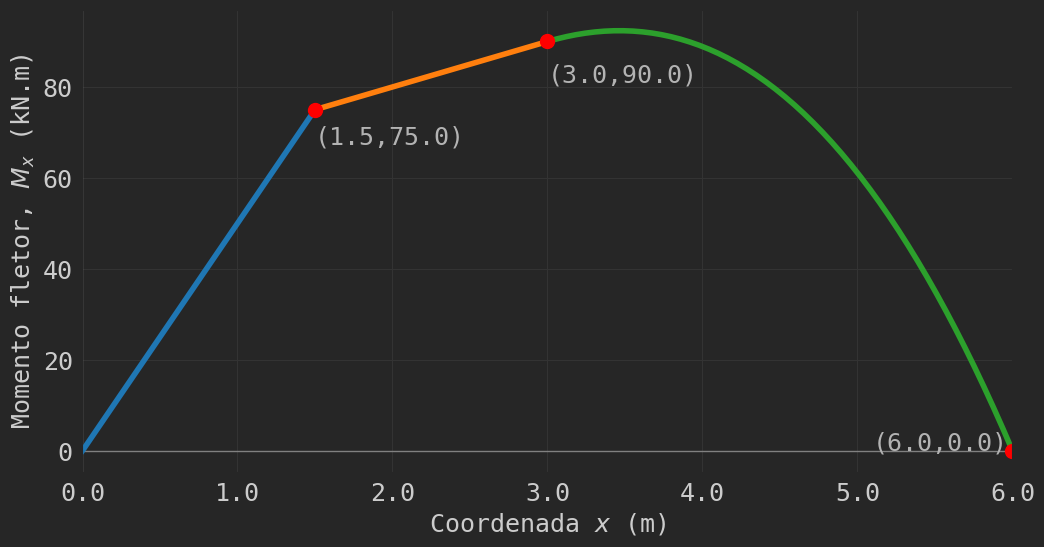

In [17]:

declive = (d.QD-d.QC)/(d.L/2)

mAB = lambda x: Ay*x
mBC = lambda x: Ay*x - d.P*(x-d.L/4)
mCD = lambda x: Ay*x - d.P*(x-d.L/4) - d.QC/2*(x-d.L/2)**2 - declive/(2*3)*(x-d.L/2)**3

print(f'mAB = {mAB(x)}')
print(f'mBC = {mBC(x)}')
print(f'mCD = {printsymSF(mCD(x))}')

# AB
ymAB = sy2array(mAB(x),xAB)
# BC
ymBC = sy2array(mBC(x),xBC)
# CD
ymCD = sy2array(mCD(x),xCD)

fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=1,color=(.5, .5, .5))
plt.plot(xAB,ymAB,linewidth=4)
plt.plot(xBC,ymBC,linewidth=4)
plt.plot(xCD,ymCD,linewidth=4)
plt.plot(xBC[0],ymBC[0],'ro',markersize=10)
plt.text(xBC[0],ymBC[0]*.9,f'({xBC[0]:.1f},{ymBC[0]:.1f})',fontsize=18)
plt.plot(xBC[-1],ymBC[-1],'ro',markersize=10)
plt.text(xBC[-1],ymBC[-1]*.9,f'({xBC[-1]:.1f},{ymBC[-1]:.1f})',fontsize=18)
plt.plot(xCD[-1],ymCD[-1],'ro',markersize=10)
plt.text(xCD[-1]*.85,ymCD[-1]*1.,f'({xCD[-1]:.1f},{ymCD[-1]:.1f})',fontsize=18)
plt.xlabel(r'Coordenada $x$ (m)')
plt.ylabel(r'Momento fletor, $M_{x}$ (kN.m)')
plt.xlim(0,d.L)
#plt.ylim(-100,50)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
xrang = np.arange(0, d.L*1.1, 1.0)
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
plt.grid(True)
plt.show()

#### c) Determine a equação da linha elástica.

#### Resumo

As expressões $⟨x − a⟩^0$, $⟨x − a⟩^1$, $⟨x − a⟩^2$ são designadas por funçoes singulares. Quando $n ≥ 0$,

\begin{equation*}
⟨x − a⟩^n = 
\begin{cases}
(x − a)^n & \quad\text{se } x \ge a \\
0 & \quad\text{se } x < a \\
\end{cases}
\end{equation*}

Nota-se que, os parênteses angulares ⟨ ⟩ devem ser substituídos por parênteses curvos ( ) quando $x ≥ a$ e por zero quando $x < a$.


#### Equação da linha elástica:

Desenvolvendo,

\begin{equation*}
\frac{\partial² v(x)}{\partial x²} = \frac{M(x)}{EI}
=
\left[
A_y x  - P <x-\frac{L}{4}>^1
- \frac{Q_C}{2}<x-\frac{L}{2}>^2
- \frac{m}{6}<x-\frac{L}{2}>^3
\right] / EI
\end{equation*}

com,

\begin{equation*}
m = \frac{(Q_D-Q_C)}{(x_D-x_C)} = \frac{(Q_D-Q_C)}{(L-L/2)}
= \frac{(Q_D-Q_C)}{L/2}
\end{equation*}

Por integração por separação de variáveis, obtem-se

\begin{equation*}
\theta(x) = \frac{\partial v(x)}{\partial x} =
\left[
\frac{A_y}{2} x²  - \frac{P}{2}<x-\frac{L}{4}>^2
- \frac{Q_C}{6}<x-\frac{L}{2}>^3
- \frac{m}{24}<x-\frac{L}{2}>^4
+ C_1
\right] / EI
\end{equation*}

integrando novamente resulta

\begin{equation*}
v(x) =
\left[
\frac{A_y}{6} x³  - \frac{P}{6}<x-\frac{L}{4}>^3
- \frac{Q_C}{24}<x-\frac{L}{2}>^4
- \frac{m}{120}<x-\frac{L}{2}>^5
+ C_1 x
+ C_2
\right] / EI
\end{equation*}

As constantes de integração $C_1$ e $C_2$ são determinadas pelas condições de fronteira.

\begin{equation*}
x = 0 \quad\Rightarrow\quad y(0) = 0
\quad\therefore\quad
C_2 = 0
\end{equation*}

\begin{equation*}
x = L \quad\Rightarrow\quad y(L) = 0
\end{equation*}


In [18]:
c1, c2 = sy.symbols('c1 c2')

print('::: eq. cond. fronteira :::')
def flex(x):
    m1 = Ay/6*x**3
    m2 = - d.P/6*(x-d.L/4)**3
    m3 = - d.QC/24*(x-d.L/2)**4
    m4 = - declive/120*(x-d.L/2)**5
    print(m1, m2, m3, m4)
    return m1 + m2 + m3 + m4 + c1*x + c2

C2 = 0
print(f'C2 = {C2} [N.m]')

eqC1 = flex(d.L).subs(c2,C2)
sol = solve(eqC1,c1)
C1 = sol[0]
print(f'eqC1 = {eqC1} | C1 = {C1:.2f} [N.m]')

::: eq. cond. fronteira :::
C2 = 0 [N.m]
1800.00000000000 -607.5 -67.5 -13.500000000000002
eqC1 = 6.0*c1 + 1111.5 | C1 = -185.25 [N.m]


In [19]:
def theta_(x):
    return sy.diff(flex(x).subs({(c1,C1),(c2,C2)}),x)/EI

def y_(x):
    return flex(x).subs({(c1,C1),(c2,C2)})/EI

print(f'1. theta(x) = {printsymSF(theta_(x))}')
eqtzer = theta_(x)
sol = solve(eqtzer,x)
r_ = [sol[0],sol[1],sol[2],sol[3]]
print(f'2. Raizes da função (theta = 0) :: ({r_[0]:.3f},{r_[1]:.3f},{r_[2]:.3f},{r_[3]:.3f})')
xmax = r_[2]
print(f'3. >>>> theta = 0 | xma = {xmax:.3f} m')

print('\n::: Deflexao maxima :::')
ymax = y_(xmax)
print(f'ymax({xmax:.3f}) = {ymax:.3e} m')

8.33333333333333*x**3 -22.5*(0.666666666666667*x - 1)**3 -67.5*(0.333333333333333*x - 1)**4 -13.5*(0.333333333333333*x - 1)**5
1. theta(x) = -0.277777777777778*x**4 + 20.0*x**2 - 162.75
8.33333333333333*x**3 -22.5*(0.666666666666667*x - 1)**3 -67.5*(0.333333333333333*x - 1)**4 -13.5*(0.333333333333333*x - 1)**5
2. Raizes da função (theta = 0) :: (-7.915,-3.058,3.058,7.915)
3. >>>> theta = 0 | xma = 3.058 m

::: Deflexao maxima :::
238.339644669115 -25.2196384062722 -9.53016903296186e-6 -3.69470532901252e-8
ymax(3.058) = -3.534e+2 m


In [20]:
print('\n::: Rotação A :::')
thetaA = theta_(x).subs(x,0.)
print(f'theta A ({0}) = {printsymSF(thetaA):.3e} [radianos]')

print('\n::: Rotação D :::')
thetaD = theta_(x).subs(x,d.L)
print(f'theta D ({d.L}) = {printsymSF(thetaD):.3e} [radianos]')


::: Rotação A :::
8.33333333333333*x**3 -22.5*(0.666666666666667*x - 1)**3 -67.5*(0.333333333333333*x - 1)**4 -13.5*(0.333333333333333*x - 1)**5
theta A (0) = -1.628e+2 [radianos]

::: Rotação D :::
8.33333333333333*x**3 -22.5*(0.666666666666667*x - 1)**3 -67.5*(0.333333333333333*x - 1)**4 -13.5*(0.333333333333333*x - 1)**5
theta D (6.0) = 1.972e+2 [radianos]


flexAB = x*(8.333*x**2 - 185.25)
flexBC = 1.66666666666667*x**3 + 30.0*x**2 - 230.25*x + 22.5
flexCD = -0.0555555555555556*x**5 + 1.11022302462516e-16*x**4 + 6.66666666666667*x**3 + 1.77635683940025e-15*x**2 - 162.75*x - 31.5


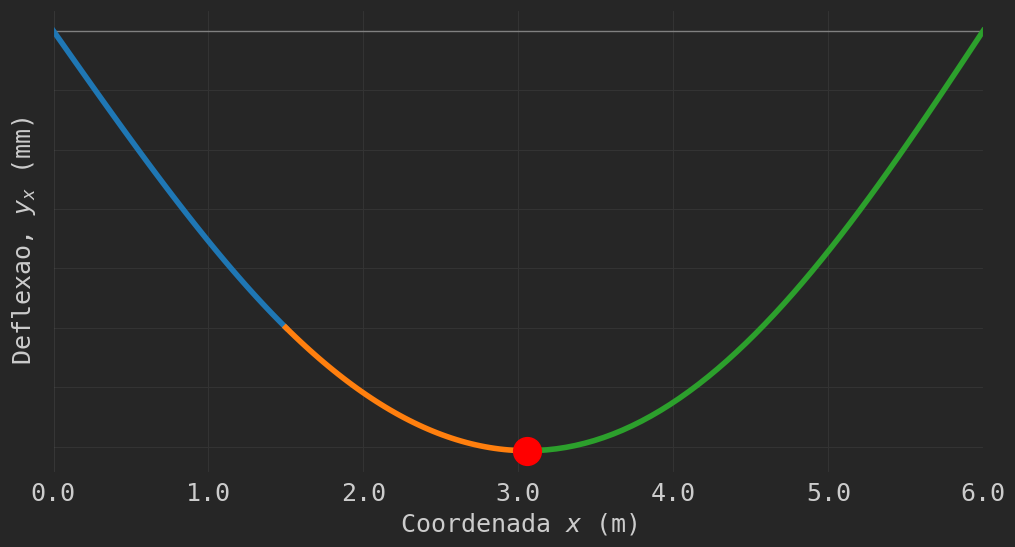

In [21]:
xAB = np.linspace(0,d.L/4)
xBC = np.linspace(d.L/4,d.L/2)
xCD = np.linspace(d.L/2,d.L)

def sy2array(sygunc,xlist):
    scalar_func = lambda xx: float(sygunc.evalf(subs={x: xx}))
    vector_func = np.vectorize(scalar_func)
    return vector_func(xlist)

t1 = Ay/6*x**3
t2 = - d.P/6*(x-d.L/4)**3
t3 = - d.QC/24*(x-d.L/2)**4
t4 = - declive/120*(x-d.L/2)**5

flexAB = lambda x: ( t1 + C1*x + C2 )/EI
flexBC = lambda x: ( t1 + t2 + C1*x + C2 )/EI
flexCD = lambda x: ( t1 + t2 + t3 + t4 + C1*x + C2 )/EI

print(f'flexAB = {printsymSF(flexAB(x))}')
print(f'flexBC = {printsymSF(flexBC(x))}')
print(f'flexCD = {printsymSF(flexCD(x))}')

# AB
yflexAB = sy2array(flexAB(x)*1e3,xAB)
# BC
yflexBC = sy2array(flexBC(x)*1e3,xBC)
# CD
yflexCD = sy2array(flexCD(x)*1e3,xCD)

fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=1,color=(.5, .5, .5))
plt.plot(xAB,yflexAB,linewidth=4)
plt.plot(xBC,yflexBC,linewidth=4)
plt.plot(xCD,yflexCD,linewidth=4)
plt.plot(xmax, ymax*1e3,'ro',markersize=20)
plt.xlabel(r'Coordenada $x$ (m)')
plt.ylabel(r'Deflexao, $y_{x}$ (mm)')
plt.xlim(0,d.L)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
ax.set_yticklabels([])
xrang = np.arange(0, d.L*1.1, 1.0)
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
plt.grid(True)
plt.show()

rotAB = 25.0*x**2 - 185.25
rotBC = 5.0*x**2 + 60.0*x - 230.25
rotCD = -0.277777777777778*x**4 + 20.0*x**2 - 162.75


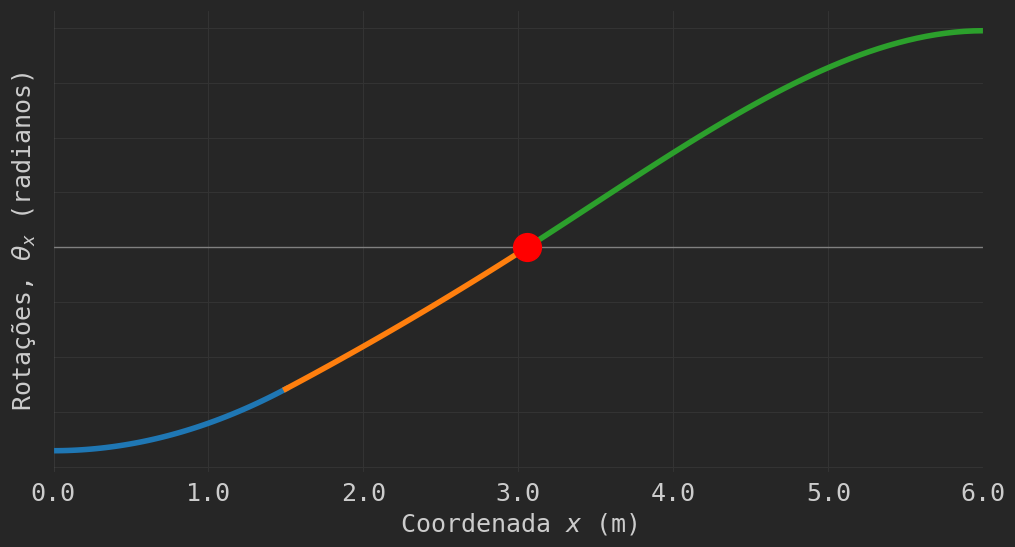

In [22]:
t5 = Ay/2*x**2
t6 = - d.P/2*(x-d.L/4)**2
t7 = - d.QC/6*(x-d.L/2)**3
t8 = - declive/24*(x-d.L/2)**4

rotAB = lambda x: ( t5 + C1)/EI
rotBC = lambda x: ( t5 + t6 + C1)/EI
rotCD = lambda x: ( t5 + t6 + t7 + t8 +C1)/EI

print(f'rotAB = {printsymSF(rotAB(x))}')
print(f'rotBC = {printsymSF(rotBC(x))}')
print(f'rotCD = {printsymSF(rotCD(x))}')

# AB
protAB = sy2array(rotAB(x),xAB)
# BC
protBC = sy2array(rotBC(x),xBC)
# CD
protCD = sy2array(rotCD(x),xCD)

fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=1,color=(.5, .5, .5))
plt.plot(xAB,protAB,linewidth=4)
plt.plot(xBC,protBC,linewidth=4)
plt.plot(xCD,protCD,linewidth=4)
plt.plot(xmax, 0,'ro',markersize=20)
plt.xlabel(r'Coordenada $x$ (m)')
plt.ylabel(r'Rotações, $\theta_{x}$ (radianos)')
plt.xlim(0,d.L)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
ax.set_yticklabels([])
xrang = np.arange(0, d.L*1.1, 1.0)
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
plt.grid(True)
plt.show()

### Anexo: Funções de singularidade

As funções de singularidade (ou funções de descontinuidade) são uma ferramenta matemática introduzida para representar, de forma compacta e sistemática, carregamentos e reações localizados (como forças e momentos concentrados, ou descontinuidades em vigas) nas equações diferenciais da linha elástica. Essas funções permitem escrever numa única expressão contínua a equação do momento fletor, da força cortante ou da deflexão, mesmo em situações com mudanças bruscas no carregamento.

As expressões $⟨x − a⟩^0$, $⟨x − a⟩^1$, $⟨x − a⟩^2$ são designadas por funçoes singulares. Quando $n ≥ 0$,

\begin{equation*}
⟨x − a⟩^n = 
\begin{cases}
(x − a)^n & \quad\text{se } x \ge a \\
0 & \quad\text{se } x < a \\
\end{cases}
\end{equation*}

Nota-se que, os parênteses angulares ⟨ ⟩ devem ser substituídos por parênteses curvos ( ) quando $x ≥ a$ e por zero quando $x < a$.

Segue da definição de funções singularidades que,

\begin{equation*}
\int ⟨x − a⟩^n \mathrm{d}x = \frac{1}{n+1} 
⟨x − a⟩^{n+1} \quad\textrm{se}\quad n \ge 0
\end{equation*}

e 

\begin{equation*}
\frac{d}{dx} ⟨x − a⟩^n = n⟨x − a⟩^{n-1} \quad\textrm{se}\quad n \ge 1
\end{equation*}

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Formulario/singularity_functions.png"
width="900">

---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>
